<a href="https://colab.research.google.com/github/Watchman77/AR_Pure_SolarFlares_72h_Dataset/blob/main/gray_box_solar_flare_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!git clone https://github.com/Watchman77/gray-box-solar-flare-forecasting.git
%cd gray-box-solar-flare-forecasting
!nvidia-smi

fatal: destination path 'gray-box-solar-flare-forecasting' already exists and is not an empty directory.
/content/gray-box-solar-flare-forecasting
Wed Oct  7 16:02:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Def

In [ ]:
!pip install -r requirements-training.txt

In [ ]:
!pwd
!git log -1 --oneline
!ls

/content/gray-box-solar-flare-forecasting
67d80ad (HEAD -> main, origin/main, origin/HEAD) Validate frozen three-state policy outputs
AGENTS.md			  requirements-audit.txt
configs				  requirements-notebook.txt
data				  requirements-training-lock.txt
docs				  requirements-training.txt
gray-box-solar-flare-forecasting  results
notebooks			  scripts
README.md			  tests


In [ ]:
!python scripts/train_multihorizon_sharp.py \
  --horizon 24 \
  --output-dir results/24h_graybox/sharp_training_v1

python3: can't open file '/content/gray-box-solar-flare-forecasting/scripts/train_multihorizon_sharp.py': [Errno 2] No such file or directory


In [ ]:
%cd /content/gray-box-solar-flare-forecasting/gray-box-solar-flare-forecasting
!git pull origin main
!git log -1 --oneline

/content/gray-box-solar-flare-forecasting/gray-box-solar-flare-forecasting
From https://github.com/Watchman77/gray-box-solar-flare-forecasting
 * branch            main       -> FETCH_HEAD
Already up to date.
5725e36 (HEAD -> main, origin/main, origin/HEAD) Enable CUDA for horizon SHARP training


In [ ]:
!test -f scripts/train_multihorizon_sharp.py && echo "runner found"
!test -f data/processed/gray_box_aligned_v1/sharp.npy && echo "SHARP tensor found"
!test -f data/processed/gray_box_multihorizon_labels_24h_v1/candidate_labels_24h.csv.gz && echo "24h labels found"
!test -f data/processed/gray_box_multihorizon_labels_3h_v1/candidate_labels_3h.csv.gz && echo "3h labels found"

runner found


In [ ]:
!test -f data/processed/gray_box_aligned_v1/sharp.npy && echo "SHARP tensor found" || echo "SHARP tensor missing"
!test -f data/processed/gray_box_multihorizon_labels_24h_v1/candidate_labels_24h.csv.gz && echo "24h labels found" || echo "24h labels missing"
!test -f data/processed/gray_box_multihorizon_labels_3h_v1/candidate_labels_3h.csv.gz && echo "3h labels found" || echo "3h labels missing"

SHARP tensor missing
24h labels missing
3h labels missing


In [ ]:
!find /content/drive/MyDrive -name sharp.npy
!find /content/drive/MyDrive -name candidate_labels_24h.csv.gz
!find /content/drive/MyDrive -name candidate_labels_3h.csv.gz

In [ ]:
!ls -lah results/24h_graybox/

total 24K
drwxr-xr-x  2 root root 4.0K Oct  7 15:22 .
drwxr-xr-x 42 root root 4.0K Oct  7 15:22 ..
-rw-r--r--  1 root root    0 Oct  7 15:22 .gitkeep
-rw-r--r--  1 root root 1.1K Oct  7 15:22 label_build_receipt.json
-rw-r--r--  1 root root 1.7K Oct  7 15:22 label_quality_audit.json
-rw-r--r--  1 root root 4.4K Oct  7 15:22 matched_support_audit.json


In [ ]:
!cat results/24h_graybox/sharp_training_v1/summary.json

cat: results/24h_graybox/sharp_training_v1/summary.json: No such file or directory


In [ ]:
!find /content/drive -type f -name "sharp.npy" 2>/dev/null
!find /content/drive -type f -name "candidate_labels_24h.csv.gz" 2>/dev/null
!find /content/drive -type f -name "candidate_labels_3h.csv.gz" 2>/dev/null

In [ ]:
!find /content/drive/MyDrive -type d -name "gray_box_aligned_v1" 2>/dev/null

/content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_aligned_v1


In [ ]:
!cp -r /content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_aligned_v1 data/processed/
!cp -r /content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_multihorizon_labels_24h_v1 data/processed/
!cp -r /content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_multihorizon_labels_3h_v1 data/processed/

In [ ]:
!cp -r /content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_multihorizon_labels_24h_v1 data/processed/
!cp -r /content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_multihorizon_labels_3h_v1 data/processed/

In [ ]:
!find /content/drive/MyDrive -type f | grep -E "sharp.npy|candidate_labels_(24h|3h)"

In [ ]:
!find /content/drive/MyDrive -type d -name "gray_box_multihorizon_labels_24h_v1" 2>/dev/null
!find /content/drive/MyDrive -type d -name "gray_box_multihorizon_labels_3h_v1" 2>/dev/null

/content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_multihorizon_labels_24h_v1
/content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_multihorizon_labels_3h_v1


In [ ]:
%cd /content/gray-box-solar-flare-forecasting/gray-box-solar-flare-forecasting
!mkdir -p data/processed

!cp -r /content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_aligned_v1 data/processed/
!cp -r /content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_multihorizon_labels_24h_v1 data/processed/
!cp -r /content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_multihorizon_labels_3h_v1 data/processed/

/content/gray-box-solar-flare-forecasting/gray-box-solar-flare-forecasting


In [ ]:
!ls -lh data/processed/gray_box_aligned_v1/sharp.npy
!ls -lh data/processed/gray_box_multihorizon_labels_24h_v1/candidate_labels_24h.csv.gz
!ls -lh data/processed/gray_box_multihorizon_labels_3h_v1/candidate_labels_3h.csv.gz

ls: cannot access 'data/processed/gray_box_aligned_v1/sharp.npy': No such file or directory
ls: cannot access 'data/processed/gray_box_multihorizon_labels_24h_v1/candidate_labels_24h.csv.gz': No such file or directory
ls: cannot access 'data/processed/gray_box_multihorizon_labels_3h_v1/candidate_labels_3h.csv.gz': No such file or directory


In [ ]:
!find /content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_aligned_v1 -maxdepth 2 -type f | head
!find /content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_multihorizon_labels_24h_v1 -maxdepth 2 -type f
!find /content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_multihorizon_labels_3h_v1 -maxdepth 2 -type f

/content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_aligned_v1/y_patch_72h.npy
/content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_aligned_v1/y_patch_48h.npy
/content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_aligned_v1/known_patch_48h.npy
/content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_aligned_v1/manifest.json
/content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_aligned_v1/y_primary_48h.npy
/content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_aligned_v1/data_dictionary.csv
/content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_aligned_v1/known_patch_72h.npy
/content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_aligned_v1/sharp_missing.npy
/content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_aligned_v1/goes_events.csv.gz
/content/drive/MyDri

In [ ]:
%cd /content/gray-box-solar-flare-forecasting/gray-box-solar-flare-forecasting
!mkdir -p data/processed

!cp -rv /content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_aligned_v1 ./data/processed/
!cp -rv /content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_multihorizon_labels_24h_v1 ./data/processed/
!cp -rv /content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_multihorizon_labels_3h_v1 ./data/processed/

/content/gray-box-solar-flare-forecasting/gray-box-solar-flare-forecasting
'/content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_aligned_v1/known_patch_72h.npy' -> './data/processed/gray_box_aligned_v1/known_patch_72h.npy'
'/content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_aligned_v1/data_dictionary.csv' -> './data/processed/gray_box_aligned_v1/data_dictionary.csv'
'/content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_aligned_v1/y_primary_48h.npy' -> './data/processed/gray_box_aligned_v1/y_primary_48h.npy'
'/content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_aligned_v1/manifest.json' -> './data/processed/gray_box_aligned_v1/manifest.json'
'/content/drive/MyDrive/gray-box-solar-flare-forecasting/data/processed/gray_box_aligned_v1/known_patch_48h.npy' -> './data/processed/gray_box_aligned_v1/known_patch_48h.npy'
'/content/drive/MyDrive/gray-box-solar-flare-forecasting/data/proc

In [ ]:
!python -u scripts/train_multihorizon_sharp.py \
  --horizon 24 \
  --output-dir results/24h_graybox/sharp_training_v1

/content/gray-box-solar-flare-forecasting/gray-box-solar-flare-forecasting/scripts/train_multihorizon_sharp.py:19: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  ii=torch.as_tensor(order[s:s+256],dtype=torch.long,device=device); opt.zero_grad(set_to_none=True); loss=loss_fn(model(x[ii]),torch.as_tensor(y[ii.cpu().numpy()],dtype=torch.float32,device=device)); loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),1.); opt.step(); total+=float(loss)*len(ii)
{
  "status": "completed_exploratory_training",
  "horizon_hours": 24,
  "device": "cuda",
  "gpu_name": "Tesla T4",
  "roles": {
    "retrospective_cycle25": 41101,
    "train": 27470,
    "policy_validation": 13320,
    "supplementary_2026": 11808,
    "unknown_label_excluded": 7207,
    "conformal_calibration": 4550,
    "model_va

In [ ]:
!cp -r results/24h_graybox/sharp_training_v1 \
  /content/drive/MyDrive/gray-box-solar-flare-forecasting/results/24h_graybox/


**3h**
---



In [ ]:
!python -u scripts/train_multihorizon_sharp.py \
  --horizon 3 \
  --output-dir results/3h_graybox/sharp_training_v1

/content/gray-box-solar-flare-forecasting/gray-box-solar-flare-forecasting/scripts/train_multihorizon_sharp.py:19: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  ii=torch.as_tensor(order[s:s+256],dtype=torch.long,device=device); opt.zero_grad(set_to_none=True); loss=loss_fn(model(x[ii]),torch.as_tensor(y[ii.cpu().numpy()],dtype=torch.float32,device=device)); loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),1.); opt.step(); total+=float(loss)*len(ii)
{
  "status": "completed_exploratory_training",
  "horizon_hours": 3,
  "device": "cuda",
  "gpu_name": "Tesla T4",
  "roles": {
    "retrospective_cycle25": 44735,
    "train": 28505,
    "policy_validation": 13485,
    "supplementary_2026": 12097,
    "model_validation": 4769,
    "conformal_calibration": 4737,
    "probability_cal

In [ ]:
!cp -r results/3h_graybox/sharp_training_v1 \
  /content/drive/MyDrive/gray-box-solar-flare-forecasting/results/3h_graybox/

In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
)

def hss_score(y, p, threshold):
    pred = p >= threshold
    tp = int(((pred == 1) & (y == 1)).sum())
    tn = int(((pred == 0) & (y == 0)).sum())
    fp = int(((pred == 1) & (y == 0)).sum())
    fn = int(((pred == 0) & (y == 1)).sum())

    total = tp + tn + fp + fn
    expected = ((tp + fn) * (tp + fp) + (fp + tn) * (fn + tn)) / total
    denominator = total - expected

    return 2 * (tp + tn - expected) / denominator if denominator else np.nan

def threshold_metrics(y, p, threshold):
    pred = p >= threshold
    positive = y == 1
    negative = y == 0

    tp = int((pred & positive).sum())
    tn = int((~pred & negative).sum())
    fp = int((pred & negative).sum())
    fn = int((~pred & positive).sum())

    recall = tp / (tp + fn) if tp + fn else np.nan
    specificity = tn / (tn + fp) if tn + fp else np.nan

    return {
        "cases": int(len(y)),
        "positives": int(y.sum()),
        "threshold": float(threshold),
        "tss": float(recall + specificity - 1),
        "hss": float(hss_score(y, p, threshold)),
        "recall": float(recall),
        "specificity": float(specificity),
        "precision": float(tp / (tp + fp)) if tp + fp else np.nan,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "brier": float(brier_score_loss(y, p)),
        "log_loss": float(log_loss(y, np.clip(p, 1e-7, 1 - 1e-7))),
        "average_precision": float(average_precision_score(y, p)),
        "roc_auc": float(roc_auc_score(y, p)) if len(np.unique(y)) == 2 else np.nan,
    }

def choose_threshold(frame):
    validation = frame[
        (frame["role"] == "model_validation") &
        frame["label"].isin([0, 1]) &
        frame["probability_gru_mean"].notna()
    ].copy()

    candidates = np.unique(
        np.r_[0.0, 1.0, validation["probability_gru_mean"].to_numpy()]
    )

    records = [
        threshold_metrics(
            validation["label"].to_numpy(dtype=int),
            validation["probability_gru_mean"].to_numpy(dtype=float),
            threshold,
        )
        for threshold in candidates
    ]

    scores = pd.DataFrame(records).sort_values(
        ["tss", "hss", "recall", "threshold"],
        ascending=[False, False, False, True],
    )

    return float(scores.iloc[0]["threshold"]), scores

def evaluate_horizon(horizon):
    path = Path(f"results/{horizon}h_graybox/sharp_training_v1/predictions.csv.gz")
    frame = pd.read_csv(path)

    threshold, threshold_search = choose_threshold(frame)

    rows = []
    for role, part in frame.groupby("role", sort=False):
        part = part[
            part["label"].isin([0, 1]) &
            part["probability_gru_mean"].notna()
        ]

        if len(part) == 0:
            continue

        result = threshold_metrics(
            part["label"].to_numpy(dtype=int),
            part["probability_gru_mean"].to_numpy(dtype=float),
            threshold,
        )
        result["horizon_hours"] = horizon
        result["role"] = role
        rows.append(result)

    output = Path(f"results/{horizon}h_graybox/sharp_threshold_audit_v1")
    output.mkdir(parents=True, exist_ok=True)

    pd.DataFrame(rows).to_csv(output / "metrics_by_role.csv", index=False)
    threshold_search.to_csv(output / "threshold_search_model_validation.csv", index=False)

    summary = {
        "horizon_hours": horizon,
        "selected_threshold": threshold,
        "selection_role": "model_validation",
        "metrics_file": str(output / "metrics_by_role.csv"),
        "threshold_search_file": str(output / "threshold_search_model_validation.csv"),
    }

    (output / "summary.json").write_text(json.dumps(summary, indent=2))
    return summary, pd.DataFrame(rows)

summaries = []
all_metrics = []

for horizon in [24, 3]:
    summary, metrics_table = evaluate_horizon(horizon)
    summaries.append(summary)
    all_metrics.append(metrics_table)

print(json.dumps(summaries, indent=2))
display(pd.concat(all_metrics, ignore_index=True))

[
  {
    "horizon_hours": 24,
    "selected_threshold": 0.0310642545421918,
    "selection_role": "model_validation",
    "metrics_file": "results/24h_graybox/sharp_threshold_audit_v1/metrics_by_role.csv",
    "threshold_search_file": "results/24h_graybox/sharp_threshold_audit_v1/threshold_search_model_validation.csv"
  },
  {
    "horizon_hours": 3,
    "selected_threshold": 0.0249391943216323,
    "selection_role": "model_validation",
    "metrics_file": "results/3h_graybox/sharp_threshold_audit_v1/metrics_by_role.csv",
    "threshold_search_file": "results/3h_graybox/sharp_threshold_audit_v1/threshold_search_model_validation.csv"
  }
]


,cases,positives,threshold,tss,hss,recall,specificity,precision,tp,tn,fp,fn,brier,log_loss,average_precision,roc_auc,horizon_hours,role
0,27470,738,0.031064,0.732555,0.436580,0.869919,0.862637,0.148818,642,23060,3672,96,0.018859,0.070994,0.456089,0.944479,24,train
1,4494,246,0.031064,0.696552,0.575929,0.878049,0.818503,0.218845,216,3477,771,30,0.036085,0.129153,0.556556,0.928013,24,model_validation
2,3483,106,0.031064,0.728918,0.412847,0.896226,0.832692,0.143939,95,2812,565,11,0.022105,0.082556,0.412379,0.936840,24,probability_calibration
3,4550,201,0.031064,0.849578,0.744078,0.975124,0.874454,0.264151,196,3803,546,5,0.027330,0.088409,0.602453,0.969875,24,conformal_calibration
4,13320,171,0.031064,0.845728,0.456284,0.918129,0.927599,0.141569,157,12197,952,14,0.008866,0.034456,0.438483,0.969364,24,policy_validation
5,41101,1825,0.031064,0.624668,0.455158,0.803836,0.820832,0.172507,1467,32239,7037,358,0.036943,0.135142,0.303176,0.889696,24,retrospective_cycle25
6,11808,544,0.031064,0.338768,0.411083,0.431985,0.906783,0.182879,235,10214,1050,309,0.039808,0.182548,0.259916,0.817718,24,supplementary_2026
7,28505,140,0.024939,0.697972,0.184467,0.764286,0.933686,0.053823,107,26484,1881,33,0.004616,0.021150,0.109034,0.951179,3,train
8,4769,60,0.024939,0.793608,0.312910,0.900000,0.893608,0.097297,54,4208,501,6,0.010748,0.041847,0.335123,0.954640,3,model_validation
9,3942,23,0.024939,0.710652,0.203439,0.782609,0.928043,0.060000,18,3637,282,5,0.005380,0.023820,0.187142,0.953238,3,probability_calibration


In [ ]:
!cp -r results/24h_graybox/sharp_threshold_audit_v1 \
  /content/drive/MyDrive/gray-box-solar-flare-forecasting/results/24h_graybox/

!cp -r results/3h_graybox/sharp_threshold_audit_v1 \
  /content/drive/MyDrive/gray-box-solar-flare-forecasting/results/3h_graybox/

In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss

def fit_calibrators(frame):
    usable = frame[
        frame["label"].isin([0, 1]) &
        frame["probability_gru_mean"].notna()
    ].copy()

    calibration = usable[usable["role"] == "probability_calibration"].copy()
    calibration = calibration.sort_values("forecast_case_id").reset_index(drop=True)

    cut = int(len(calibration) * 0.70)
    fit_part = calibration.iloc[:cut]
    select_part = calibration.iloc[cut:]

    x_fit = fit_part["probability_gru_mean"].to_numpy()
    y_fit = fit_part["label"].to_numpy(dtype=int)
    x_select = select_part["probability_gru_mean"].to_numpy()
    y_select = select_part["label"].to_numpy(dtype=int)

    raw_map = lambda p: np.asarray(p, dtype=float)

    platt = LogisticRegression(
        C=1e6,
        solver="lbfgs",
        max_iter=1000,
    )
    platt.fit(x_fit.reshape(-1, 1), y_fit)

    isotonic = IsotonicRegression(
        out_of_bounds="clip",
        y_min=0.0,
        y_max=1.0,
    )
    isotonic.fit(x_fit, y_fit)

    maps = {
        "raw": raw_map,
        "platt": lambda p: platt.predict_proba(
            np.asarray(p).reshape(-1, 1)
        )[:, 1],
        "isotonic": lambda p: isotonic.predict(
            np.asarray(p, dtype=float)
        ),
    }

    selection = []
    for name, mapper in maps.items():
        pred = np.clip(mapper(x_select), 1e-7, 1 - 1e-7)
        selection.append({
            "method": name,
            "selection_brier": float(brier_score_loss(y_select, pred)),
            "selection_log_loss": float(log_loss(y_select, pred)),
        })

    selection_table = pd.DataFrame(selection).sort_values(
        ["selection_brier", "selection_log_loss", "method"]
    )
    selected_method = selection_table.iloc[0]["method"]

    rows = []
    for role, part in usable.groupby("role", sort=False):
        raw = part["probability_gru_mean"].to_numpy(dtype=float)
        y = part["label"].to_numpy(dtype=int)

        for name, mapper in maps.items():
            pred = np.clip(mapper(raw), 1e-7, 1 - 1e-7)
            rows.append({
                "horizon_hours": horizon,
                "role": role,
                "method": name,
                "cases": len(y),
                "positives": int(y.sum()),
                "brier": float(brier_score_loss(y, pred)),
                "log_loss": float(log_loss(y, pred)),
            })

    return maps, selection_table, pd.DataFrame(rows), selected_method

all_results = []

for horizon in [24, 3]:
    path = Path(
        f"results/{horizon}h_graybox/"
        "sharp_training_v1/predictions.csv.gz"
    )
    frame = pd.read_csv(path)

    maps, selection, metrics_table, selected_method = fit_calibrators(frame)

    output = Path(
        f"results/{horizon}h_graybox/"
        "sharp_calibration_v1"
    )
    output.mkdir(parents=True, exist_ok=True)

    selection.to_csv(output / "calibration_selection.csv", index=False)
    metrics_table.to_csv(output / "calibration_metrics.csv", index=False)

    summary = {
        "horizon_hours": horizon,
        "selected_method": selected_method,
        "selection_role": "internal_late_probability_calibration_block",
        "methods": ["raw", "platt", "isotonic"],
        "future_roles_not_used_for_selection": [
            "conformal_calibration",
            "policy_validation",
            "retrospective_cycle25",
            "supplementary_2026",
        ],
    }

    (output / "summary.json").write_text(
        json.dumps(summary, indent=2)
    )

    print(json.dumps(summary, indent=2))
    display(selection)
    display(metrics_table)

    all_results.append(metrics_table)

{
  "horizon_hours": 24,
  "selected_method": "raw",
  "selection_role": "internal_late_probability_calibration_block",
  "methods": [
    "raw",
    "platt",
    "isotonic"
  ],
  "future_roles_not_used_for_selection": [
    "conformal_calibration",
    "policy_validation",
    "retrospective_cycle25",
    "supplementary_2026"
  ]
}


,method,selection_brier,selection_log_loss
0,raw,0.026890,0.091451
1,platt,0.027847,0.108671
2,isotonic,0.028362,0.098472


,horizon_hours,role,method,cases,positives,brier,log_loss
0,24,train,raw,27470,738,0.018859,0.070994
1,24,train,platt,27470,738,0.019356,0.079771
2,24,train,isotonic,27470,738,0.019272,0.081448
3,24,model_validation,raw,4494,246,0.036085,0.129153
4,24,model_validation,platt,4494,246,0.036276,0.142624
5,24,model_validation,isotonic,4494,246,0.036145,0.140871
6,24,probability_calibration,raw,3483,106,0.022105,0.082556
7,24,probability_calibration,platt,3483,106,0.023240,0.092736
8,24,probability_calibration,isotonic,3483,106,0.021514,0.078578
9,24,conformal_calibration,raw,4550,201,0.027330,0.088409


{
  "horizon_hours": 3,
  "selected_method": "platt",
  "selection_role": "internal_late_probability_calibration_block",
  "methods": [
    "raw",
    "platt",
    "isotonic"
  ],
  "future_roles_not_used_for_selection": [
    "conformal_calibration",
    "policy_validation",
    "retrospective_cycle25",
    "supplementary_2026"
  ]
}


,method,selection_brier,selection_log_loss
1,platt,0.006043,0.027918
2,isotonic,0.006122,0.027127
0,raw,0.006199,0.027225


,horizon_hours,role,method,cases,positives,brier,log_loss
0,3,train,raw,28505,140,0.004616,0.021150
1,3,train,platt,28505,140,0.005948,0.026389
2,3,train,isotonic,28505,140,0.007379,0.069378
3,3,model_validation,raw,4769,60,0.010748,0.041847
4,3,model_validation,platt,4769,60,0.010607,0.042512
5,3,model_validation,isotonic,4769,60,0.012368,0.098025
6,3,probability_calibration,raw,3942,23,0.005380,0.023820
7,3,probability_calibration,platt,3942,23,0.005392,0.025930
8,3,probability_calibration,isotonic,3942,23,0.004995,0.021582
9,3,conformal_calibration,raw,4737,47,0.008722,0.034208


In [ ]:
!cp -r results/24h_graybox/sharp_calibration_v1 \
  /content/drive/MyDrive/gray-box-solar-flare-forecasting/results/24h_graybox/

!cp -r results/3h_graybox/sharp_calibration_v1 \
  /content/drive/MyDrive/gray-box-solar-flare-forecasting/results/3h_graybox/

In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression

def fit_selected_map(frame, selected_method):
    usable = frame[
        frame["label"].isin([0, 1]) &
        frame["probability_gru_mean"].notna()
    ].copy()

    cal = usable[usable["role"] == "probability_calibration"] \
        .sort_values("forecast_case_id") \
        .reset_index(drop=True)

    cut = int(len(cal) * 0.70)
    fit_part = cal.iloc[:cut]

    x_fit = fit_part["probability_gru_mean"].to_numpy()
    y_fit = fit_part["label"].to_numpy(dtype=int)

    if selected_method == "raw":
        return lambda p: np.asarray(p, dtype=float)

    if selected_method == "platt":
        model = LogisticRegression(C=1e6, solver="lbfgs", max_iter=1000)
        model.fit(x_fit.reshape(-1, 1), y_fit)
        return lambda p: model.predict_proba(
            np.asarray(p).reshape(-1, 1)
        )[:, 1]

    if selected_method == "isotonic":
        model = IsotonicRegression(
            out_of_bounds="clip",
            y_min=0.0,
            y_max=1.0,
        )
        model.fit(x_fit, y_fit)
        return lambda p: model.predict(
            np.asarray(p, dtype=float)
        )

    raise ValueError(selected_method)

def finite_sample_quantile(values, alpha):
    values = np.sort(np.asarray(values, dtype=float))
    n = len(values)
    if n == 0:
        raise ValueError("No calibration values available")
    rank = int(np.ceil((n + 1) * (1 - alpha))) - 1
    rank = min(max(rank, 0), n - 1)
    return float(values[rank])

def make_conformal_sets(probabilities, q0, q1):
    probabilities = np.asarray(probabilities, dtype=float)

    include_zero = probabilities <= q0
    include_one = (1.0 - probabilities) <= q1

    set_size = include_zero.astype(int) + include_one.astype(int)

    states = np.full(len(probabilities), "empty", dtype=object)
    states[(include_zero) & (~include_one)] = "singleton_0"
    states[(~include_zero) & (include_one)] = "singleton_1"
    states[(include_zero) & (include_one)] = "doubleton"

    return states, set_size

def conformal_metrics(frame, q0, q1, role):
    part = frame[
        (frame["role"] == role) &
        frame["label"].isin([0, 1]) &
        frame["calibrated_probability"].notna()
    ].copy()

    y = part["label"].to_numpy(dtype=int)
    p = part["calibrated_probability"].to_numpy(dtype=float)

    states, sizes = make_conformal_sets(p, q0, q1)

    covered = (
        ((y == 0) & np.isin(states, ["singleton_0", "doubleton"])) |
        ((y == 1) & np.isin(states, ["singleton_1", "doubleton"]))
    )

    flare = y == 1
    nonflare = y == 0

    return {
        "role": role,
        "cases": int(len(y)),
        "positives": int(y.sum()),
        "overall_coverage": float(covered.mean()),
        "flare_coverage": float(covered[flare].mean()) if flare.any() else np.nan,
        "nonflare_coverage": float(covered[nonflare].mean()) if nonflare.any() else np.nan,
        "singleton_rate": float(np.isin(
            states, ["singleton_0", "singleton_1"]
        ).mean()),
        "doubleton_rate": float((states == "doubleton").mean()),
        "empty_rate": float((states == "empty").mean()),
        "mean_set_size": float(sizes.mean()),
    }

selected_methods = {
    24: "raw",
    3: "platt",
}

for horizon, selected_method in selected_methods.items():
    path = Path(
        f"results/{horizon}h_graybox/"
        "sharp_training_v1/predictions.csv.gz"
    )
    frame = pd.read_csv(path)

    mapper = fit_selected_map(frame, selected_method)

    frame["calibrated_probability"] = np.nan
    usable = frame["probability_gru_mean"].notna()
    frame.loc[usable, "calibrated_probability"] = mapper(
        frame.loc[usable, "probability_gru_mean"].to_numpy()
    )

    conformal_cal = frame[
        (frame["role"] == "conformal_calibration") &
        frame["label"].isin([0, 1]) &
        frame["calibrated_probability"].notna()
    ].copy()

    y_cal = conformal_cal["label"].to_numpy(dtype=int)
    p_cal = conformal_cal["calibrated_probability"].to_numpy(dtype=float)

    # Nonconformity for class 0: p
    # Nonconformity for class 1: 1-p
    q0 = finite_sample_quantile(
        p_cal[y_cal == 0],
        alpha=0.10,
    )
    q1 = finite_sample_quantile(
        1.0 - p_cal[y_cal == 1],
        alpha=0.10,
    )

    roles_to_evaluate = [
        "conformal_calibration",
        "policy_validation",
        "retrospective_cycle25",
        "supplementary_2026",
    ]

    metrics_rows = [
        {
            "horizon_hours": horizon,
            "selected_calibration": selected_method,
            "q0_no_flare": q0,
            "q1_flare": q1,
            **conformal_metrics(frame, q0, q1, role),
        }
        for role in roles_to_evaluate
    ]

    output = Path(
        f"results/{horizon}h_graybox/"
        "sharp_conformal_v1"
    )
    output.mkdir(parents=True, exist_ok=True)

    pd.DataFrame(metrics_rows).to_csv(
        output / "conformal_metrics.csv",
        index=False,
    )

    summary = {
        "horizon_hours": horizon,
        "selected_calibration": selected_method,
        "alpha": 0.10,
        "q0_no_flare": q0,
        "q1_flare": q1,
        "calibration_role": "conformal_calibration",
        "evaluation_roles": roles_to_evaluate,
        "thresholds_frozen_before_later_roles": True,
    }

    (output / "summary.json").write_text(
        json.dumps(summary, indent=2)
    )

    print(json.dumps(summary, indent=2))
    display(pd.DataFrame(metrics_rows))

{
  "horizon_hours": 24,
  "selected_calibration": "raw",
  "alpha": 0.1,
  "q0_no_flare": 0.0472929626703262,
  "q1_flare": 0.9466516450047493,
  "calibration_role": "conformal_calibration",
  "evaluation_roles": [
    "conformal_calibration",
    "policy_validation",
    "retrospective_cycle25",
    "supplementary_2026"
  ],
  "thresholds_frozen_before_later_roles": true
}


,horizon_hours,selected_calibration,q0_no_flare,q1_flare,role,cases,positives,overall_coverage,flare_coverage,nonflare_coverage,singleton_rate,doubleton_rate,empty_rate,mean_set_size
0,24,raw,0.047293,0.946652,conformal_calibration,4550,201,0.900440,0.905473,0.900207,0.992088,0.0,0.007912,0.992088
1,24,raw,0.047293,0.946652,policy_validation,13320,171,0.950375,0.883041,0.951251,0.995646,0.0,0.004354,0.995646
2,24,raw,0.047293,0.946652,retrospective_cycle25,41101,1825,0.847619,0.720548,0.853524,0.989660,0.0,0.010340,0.989660
3,24,raw,0.047293,0.946652,supplementary_2026,11808,544,0.905403,0.373162,0.931108,0.992209,0.0,0.007791,0.992209


{
  "horizon_hours": 3,
  "selected_calibration": "platt",
  "alpha": 0.1,
  "q0_no_flare": 0.003717342525163844,
  "q1_flare": 0.9963923665640272,
  "calibration_role": "conformal_calibration",
  "evaluation_roles": [
    "conformal_calibration",
    "policy_validation",
    "retrospective_cycle25",
    "supplementary_2026"
  ],
  "thresholds_frozen_before_later_roles": true
}


,horizon_hours,selected_calibration,q0_no_flare,q1_flare,role,cases,positives,overall_coverage,flare_coverage,nonflare_coverage,singleton_rate,doubleton_rate,empty_rate,mean_set_size
0,3,platt,0.003717,0.996392,conformal_calibration,4737,47,0.900570,0.936170,0.900213,0.996833,0.003167,0.0,1.003167
1,3,platt,0.003717,0.996392,policy_validation,13485,47,0.951353,0.936170,0.951406,0.999258,0.000742,0.0,1.000742
2,3,platt,0.003717,0.996392,retrospective_cycle25,44735,341,0.865318,0.741935,0.866266,0.995730,0.004270,0.0,1.004270
3,3,platt,0.003717,0.996392,supplementary_2026,12097,146,0.935935,0.500000,0.941260,0.997768,0.002232,0.0,1.002232


In [ ]:
!cp -r results/24h_graybox/sharp_conformal_v1 \
  /content/drive/MyDrive/gray-box-solar-flare-forecasting/results/24h_graybox/

!cp -r results/3h_graybox/sharp_conformal_v1 \
  /content/drive/MyDrive/gray-box-solar-flare-forecasting/results/3h_graybox/

Next we should build a short-horizon SHARP-only diagnostic policy. Since AIA and GOES are not yet included, this is not the final multimodal Gray-Box policy.
The candidate states are:
- NORMAL: SHARP input available and conformal set is a singleton.
- DEGRADED: SHARP input available but conformal set is doubleton or empty.
- ABSTAIN: SHARP input unavailable.

In [ ]:
import json
from pathlib import Path

import numpy as np
import pandas as pd

def build_policy(horizon, selected_method):
    pred_path = Path(
        f"results/{horizon}h_graybox/"
        "sharp_training_v1/predictions.csv.gz"
    )
    conf_path = Path(
        f"results/{horizon}h_graybox/"
        "sharp_conformal_v1/conformal_metrics.csv"
    )

    frame = pd.read_csv(pred_path)

    # Reconstruct conformal thresholds from the saved summary
    summary = json.loads(Path(
        f"results/{horizon}h_graybox/"
        "sharp_conformal_v1/summary.json"
    ).read_text())

    q0 = summary["q0_no_flare"]
    q1 = summary["q1_flare"]

    p = frame["probability_gru_mean"].to_numpy(dtype=float)
    supported = np.isfinite(p)
    label = frame["label"].to_numpy(dtype=float)

    include_zero = supported & (p <= q0)
    include_one = supported & ((1.0 - p) <= q1)

    set_size = include_zero.astype(int) + include_one.astype(int)

    state = np.full(len(frame), "ABSTAIN", dtype=object)
    state[supported & (set_size == 1)] = "NORMAL"
    state[supported & (set_size != 1)] = "DEGRADED"

    frame["policy_state"] = state
    frame["conformal_set_size"] = set_size
    frame["include_no_flare"] = include_zero
    frame["include_flare"] = include_one

    rows = []

    for role, part in frame.groupby("role", sort=False):
        known = part["label"].isin([0, 1])
        part = part[known]

        if len(part) == 0:
            continue

        for policy_state in ["NORMAL", "DEGRADED", "ABSTAIN"]:
            subset = part[part["policy_state"] == policy_state]
            if len(subset) == 0:
                continue

            y = subset["label"].to_numpy(dtype=int)
            covered = (
                ((y == 0) & subset["include_no_flare"].to_numpy()) |
                ((y == 1) & subset["include_flare"].to_numpy())
            )

            rows.append({
                "horizon_hours": horizon,
                "role": role,
                "policy_state": policy_state,
                "cases": len(subset),
                "positives": int(y.sum()),
                "share_of_known_cases": len(subset) / len(part),
                "coverage": float(covered.mean()),
                "flare_cases": int(y.sum()),
                "flare_coverage": float(
                    covered[y == 1].mean()
                ) if y.sum() else np.nan,
            })

    output = Path(
        f"results/{horizon}h_graybox/"
        "sharp_policy_diagnostic_v1"
    )
    output.mkdir(parents=True, exist_ok=True)

    metrics = pd.DataFrame(rows)
    metrics.to_csv(output / "policy_metrics.csv", index=False)

    policy_summary = {
        "horizon_hours": horizon,
        "policy_type": "SHARP_only_diagnostic",
        "normal_rule": "available_and_conformal_singleton",
        "degraded_rule": "available_and_non_singleton",
        "abstain_rule": "SHARP_probability_unavailable",
        "q0_no_flare": q0,
        "q1_flare": q1,
        "selected_calibration": selected_method,
        "final_operational_policy": False,
    }

    (output / "summary.json").write_text(
        json.dumps(policy_summary, indent=2)
    )

    display(metrics)
    return metrics

policy_24 = build_policy(24, "raw")
policy_3 = build_policy(3, "platt")

,horizon_hours,role,policy_state,cases,positives,share_of_known_cases,coverage,flare_cases,flare_coverage
0,24,train,NORMAL,27200,736,0.990171,0.905846,736,0.819293
1,24,train,DEGRADED,270,2,0.009829,0.000000,2,0.000000
2,24,model_validation,NORMAL,4455,244,0.991322,0.866218,244,0.815574
3,24,model_validation,DEGRADED,39,2,0.008678,0.000000,2,0.000000
4,24,probability_calibration,NORMAL,3442,105,0.988229,0.875363,105,0.838095
5,24,probability_calibration,DEGRADED,41,1,0.011771,0.000000,1,0.000000
6,24,conformal_calibration,NORMAL,4514,196,0.992088,0.907621,196,0.928571
7,24,conformal_calibration,DEGRADED,36,5,0.007912,0.000000,5,0.000000
8,24,policy_validation,NORMAL,13262,166,0.995646,0.954532,166,0.909639
9,24,policy_validation,DEGRADED,58,5,0.004354,0.000000,5,0.000000


,horizon_hours,role,policy_state,cases,positives,share_of_known_cases,coverage,flare_cases,flare_coverage
0,3,train,NORMAL,28443,139,0.997825,0.815245,139,0.942446
1,3,train,DEGRADED,62,1,0.002175,1.000000,1,1.000000
2,3,model_validation,NORMAL,4754,60,0.996855,0.746529,60,0.966667
3,3,model_validation,DEGRADED,15,0,0.003145,1.000000,0,NaN
4,3,probability_calibration,NORMAL,3928,23,0.996449,0.801935,23,0.956522
5,3,probability_calibration,DEGRADED,14,0,0.003551,1.000000,0,NaN
6,3,conformal_calibration,NORMAL,4722,47,0.996833,0.817027,47,1.000000
7,3,conformal_calibration,DEGRADED,15,0,0.003167,1.000000,0,NaN
8,3,policy_validation,NORMAL,13467,47,0.998665,0.897527,47,0.957447
9,3,policy_validation,DEGRADED,18,0,0.001335,1.000000,0,NaN


In [ ]:
!cp -r results/24h_graybox/sharp_policy_diagnostic_v1 \
  /content/drive/MyDrive/gray-box-solar-flare-forecasting/results/24h_graybox/

!cp -r results/3h_graybox/sharp_policy_diagnostic_v1 \
  /content/drive/MyDrive/gray-box-solar-flare-forecasting/results/3h_graybox/

The next step should be a combined 3-hour/24-hour/72-hour comparison table and reliability figure. That will tell us whether the shorter horizons support a coherent multi-horizon paper before adding AIA or GOES.

In [ ]:
import pandas as pd
from pathlib import Path

rows = []

for horizon in [3, 24]:
    threshold_file = Path(
        f"results/{horizon}h_graybox/"
        "sharp_threshold_audit_v1/metrics_by_role.csv"
    )
    conformal_file = Path(
        f"results/{horizon}h_graybox/"
        "sharp_conformal_v1/conformal_metrics.csv"
    )
    policy_file = Path(
        f"results/{horizon}h_graybox/"
        "sharp_policy_diagnostic_v1/policy_metrics.csv"
    )

    threshold = pd.read_csv(threshold_file)
    conformal = pd.read_csv(conformal_file)
    policy = pd.read_csv(policy_file)

    for role in ["policy_validation", "retrospective_cycle25", "supplementary_2026"]:
        t = threshold[
            (threshold["role"] == role)
        ].iloc[0]

        c = conformal[
            (conformal["role"] == role)
        ].iloc[0]

        normal = policy[
            (policy["role"] == role) &
            (policy["policy_state"] == "NORMAL")
        ]

        normal_row = normal.iloc[0] if len(normal) else None

        rows.append({
            "horizon_hours": horizon,
            "role": role,
            "tss": t["tss"],
            "average_precision": t["average_precision"],
            "brier": t["brier"],
            "roc_auc": t["roc_auc"],
            "conformal_overall_coverage": c["overall_coverage"],
            "conformal_flare_coverage": c["flare_coverage"],
            "conformal_singleton_rate": c["singleton_rate"],
            "normal_share": (
                normal_row["share_of_known_cases"]
                if normal_row is not None else None
            ),
            "normal_flare_coverage": (
                normal_row["flare_coverage"]
                if normal_row is not None else None
            ),
        })

lead_time_table = pd.DataFrame(rows)

output = Path("results/multi_horizon_comparison_v1")
output.mkdir(parents=True, exist_ok=True)

lead_time_table.to_csv(
    output / "lead_time_comparison.csv",
    index=False,
)

display(
    lead_time_table.sort_values(
        ["role", "horizon_hours"]
    )
)

,horizon_hours,role,tss,average_precision,brier,roc_auc,conformal_overall_coverage,conformal_flare_coverage,conformal_singleton_rate,normal_share,normal_flare_coverage
0,3,policy_validation,0.860353,0.370349,0.003041,0.975364,0.951353,0.936170,0.999258,0.998665,0.957447
3,24,policy_validation,0.845728,0.438483,0.008866,0.969364,0.950375,0.883041,0.995646,0.995646,0.909639
1,3,retrospective_cycle25,0.506187,0.101905,0.007299,0.899306,0.865318,0.741935,0.995730,0.997966,0.910979
4,24,retrospective_cycle25,0.624668,0.303176,0.036943,0.889696,0.847619,0.720548,0.989660,0.989660,0.737108
2,3,supplementary_2026,0.365368,0.136722,0.011418,0.876980,0.935935,0.500000,0.997768,0.997437,0.636986
5,24,supplementary_2026,0.338768,0.259916,0.039808,0.817718,0.905403,0.373162,0.992209,0.992209,0.378731


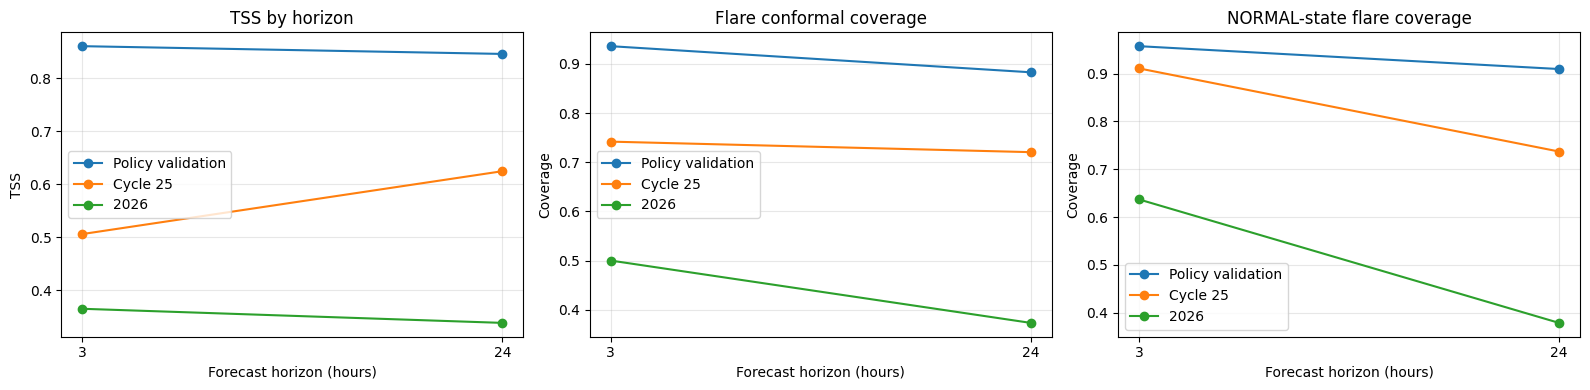

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for role, label in [
    ("policy_validation", "Policy validation"),
    ("retrospective_cycle25", "Cycle 25"),
    ("supplementary_2026", "2026"),
]:
    subset = lead_time_table[
        lead_time_table["role"] == role
    ].sort_values("horizon_hours")

    axes[0].plot(
        subset["horizon_hours"],
        subset["tss"],
        marker="o",
        label=label,
    )

    axes[1].plot(
        subset["horizon_hours"],
        subset["conformal_flare_coverage"],
        marker="o",
        label=label,
    )

    axes[2].plot(
        subset["horizon_hours"],
        subset["normal_flare_coverage"],
        marker="o",
        label=label,
    )

axes[0].set_title("TSS by horizon")
axes[1].set_title("Flare conformal coverage")
axes[2].set_title("NORMAL-state flare coverage")

for ax in axes:
    ax.set_xlabel("Forecast horizon (hours)")
    ax.set_xticks([3, 24])
    ax.grid(alpha=0.3)
    ax.legend()

axes[0].set_ylabel("TSS")
axes[1].set_ylabel("Coverage")
axes[2].set_ylabel("Coverage")

plt.tight_layout()
plt.savefig(
    output / "lead_time_comparison.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

In [ ]:
!cp -r results/multi_horizon_comparison_v1 \
  /content/drive/MyDrive/gray-box-solar-flare-forecasting/results/

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os, shutil

repo = "/content/gray-box-solar-flare-forecasting/gray-box-solar-flare-forecasting"
drive_root = "/content/drive/MyDrive/gray-box-solar-flare-forecasting"

os.makedirs(f"{drive_root}/notebooks", exist_ok=True)
os.makedirs(f"{drive_root}/results", exist_ok=True)

# Save the current notebook manually first:
# File → Save a copy in Drive

# Copy the completed results from the repository runtime to Drive
shutil.copytree(
    f"{repo}/results",
    f"{drive_root}/results",
    dirs_exist_ok=True
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/drive/MyDrive/gray-box-solar-flare-forecasting/results'

In [ ]:
%cd /content/gray-box-solar-flare-forecasting/gray-box-solar-flare-forecasting
!git status --short
!git diff --stat

/content/gray-box-solar-flare-forecasting/gray-box-solar-flare-forecasting
?? results/24h_graybox/sharp_calibration_v1/
?? results/24h_graybox/sharp_conformal_v1/
?? results/24h_graybox/sharp_policy_diagnostic_v1/
?? results/24h_graybox/sharp_threshold_audit_v1/
?? results/24h_graybox/sharp_training_v1/
?? results/3h_graybox/sharp_calibration_v1/
?? results/3h_graybox/sharp_conformal_v1/
?? results/3h_graybox/sharp_policy_diagnostic_v1/
?? results/3h_graybox/sharp_threshold_audit_v1/
?? results/3h_graybox/sharp_training_v1/
?? results/multi_horizon_comparison_v1/


In [ ]:
!du -sh results/24h_graybox results/3h_graybox results/multi_horizon_comparison_v1
!find results/24h_graybox results/3h_graybox results/multi_horizon_comparison_v1 \
  -type f -size +90M -print

2.7M	results/24h_graybox
2.7M	results/3h_graybox
144K	results/multi_horizon_comparison_v1


In [ ]:
!git add results/24h_graybox results/3h_graybox results/multi_horizon_comparison_v1
!git diff --cached --stat

 .../sharp_calibration_v1/calibration_metrics.csv   |   22 +
 .../sharp_calibration_v1/calibration_selection.csv |    4 +
 .../24h_graybox/sharp_calibration_v1/summary.json  |   16 +
 .../sharp_conformal_v1/conformal_metrics.csv       |    5 +
 .../24h_graybox/sharp_conformal_v1/summary.json    |   15 +
 .../sharp_policy_diagnostic_v1/policy_metrics.csv  |   15 +
 .../sharp_policy_diagnostic_v1/summary.json        |   11 +
 .../sharp_threshold_audit_v1/metrics_by_role.csv   |    8 +
 .../sharp_threshold_audit_v1/summary.json          |    7 +
 .../threshold_search_model_validation.csv          | 4497 ++++++++++++++++++
 .../sharp_training_v1/predictions.csv.gz           |  Bin 0 -> 1618148 bytes
 results/24h_graybox/sharp_training_v1/summary.json |   59 +
 .../sharp_calibration_v1/calibration_metrics.csv   |   22 +
 .../sharp_calibration_v1/calibration_selection.csv |    4 +
 .../3h_graybox/sharp_calibration_v1/summary.json   |   16 +
 .../sharp_conformal_v1/conformal_metrics.csv      

In [ ]:
!git config user.name "BAMIDELE AKINWUMI"
!git config user.email "119769750+Watchman77@users.noreply.github.com"

!git commit -m "Add 3h and 24h SHARP Gray-Box reliability results"
!git push origin main

[main 9d5c41f] Add 3h and 24h SHARP Gray-Box reliability results
 26 files changed, 9600 insertions(+)
 create mode 100644 results/24h_graybox/sharp_calibration_v1/calibration_metrics.csv
 create mode 100644 results/24h_graybox/sharp_calibration_v1/calibration_selection.csv
 create mode 100644 results/24h_graybox/sharp_calibration_v1/summary.json
 create mode 100644 results/24h_graybox/sharp_conformal_v1/conformal_metrics.csv
 create mode 100644 results/24h_graybox/sharp_conformal_v1/summary.json
 create mode 100644 results/24h_graybox/sharp_policy_diagnostic_v1/policy_metrics.csv
 create mode 100644 results/24h_graybox/sharp_policy_diagnostic_v1/summary.json
 create mode 100644 results/24h_graybox/sharp_threshold_audit_v1/metrics_by_role.csv
 create mode 100644 results/24h_graybox/sharp_threshold_audit_v1/summary.json
 create mode 100644 results/24h_graybox/sharp_threshold_audit_v1/threshold_search_model_validation.csv
 create mode 100644 results/24h_graybox/sharp_training_v1/predicti

In [ ]:
# Watchman77/gray-box-solar-flare-forecasting

In [ ]:
from getpass import getpass
import base64
import os
import subprocess

repo = "/content/gray-box-solar-flare-forecasting/gray-box-solar-flare-forecasting"
token = getpass("GitHub token (input hidden): ")

basic = base64.b64encode(
    f"Watchman77:{token}".encode()
).decode()

subprocess.run(
    [
        "git",
        "-c",
        f"http.extraHeader=AUTHORIZATION: Basic {basic}",
        "push",
        "origin",
        "main",
    ],
    cwd=repo,
    check=True,
)

del token, basic

GitHub token (input hidden): ··········


In [ ]:
%cd /content/gray-box-solar-flare-forecasting/gray-box-solar-flare-forecasting
!git status --short
!git log -1 --oneline

/content/gray-box-solar-flare-forecasting/gray-box-solar-flare-forecasting
9d5c41f (HEAD -> main, origin/main, origin/HEAD) Add 3h and 24h SHARP Gray-Box reliability results


In [ ]:
# HEAD -> main
# origin/main
# origin/HEAD
# 9d5c41f Add 3h and 24h SHARP Gray-Box reliability results